# Advanced Data Science – Formative Assessment 02 (FA2)
**Case Study: Usage of Social Media and Its Effects on the Mental Health of Students**
*Data Analysis Using Machine Learning & Streamlit App Deployment [CO: 1 to 4]*

**Course:** Advanced Data Science [MCA33PE17] | **Class:** SYMCA, Semester I | **Academic Year:** 2026–27
**Student Name:** _<your name>_  **PRN:** _<your PRN>_

This notebook covers **Part 1 (Data Acquisition & Preprocessing)** and **Part 2 (Model Implementation & Evaluation)**.
Part 3 (Streamlit deployment) is in `app.py`, which loads the models saved at the end of this notebook.

In [1]:
import warnings, json, os
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, joblib

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RS = 42
os.makedirs("figures", exist_ok=True); os.makedirs("models", exist_ok=True)
STATS = {}   # numbers reused in the PDF report

---
# Part 1: Data Acquisition & Preprocessing

## 1.1 Dataset Selection
**Dataset:** *Students' Social Media Addiction* survey dataset (Kaggle; 705 student responses from 110 countries).

**Problem (regression):** predict a student's self-reported **Mental_Health_Score** (higher = better wellbeing) from their social media usage, sleep, academic and background details, and find which habits are linked to lower mental health.

> Note: confirm the dataset source with the Course Teacher before final submission, as the instructions require.

## 1.2 Data Loading

In [2]:
FILE = "Students_Social_Media_Addiction.csv"
URL = "https://raw.githubusercontent.com/Harsh-1598/MindTrace---Student-Social-Media-Addiction-Risk-Modeling/main/data/Students%20Social%20Media%20Addiction.csv"
df = pd.read_csv(FILE if os.path.exists(FILE) else URL)
print("Shape:", df.shape)
df.head()

Shape: (705, 13)


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [3]:
df.info()
print("\nMissing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df.describe().T.round(2)

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    str    
 3   Academic_Level                705 non-null    str    
 4   Country                       705 non-null    str    
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    str    
 7   Affects_Academic_Performance  705 non-null    str    
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    str    
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: float64(2), i

,count,mean,std,min,25%,50%,75%,max
Student_ID,705.0,353.00,203.66,1.0,177.0,353.0,529.0,705.0
Age,705.0,20.66,1.40,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,705.0,4.92,1.26,1.5,4.1,4.8,5.8,8.5
Sleep_Hours_Per_Night,705.0,6.87,1.13,3.8,6.0,6.9,7.7,9.6
Mental_Health_Score,705.0,6.23,1.11,4.0,5.0,6.0,7.0,9.0
Conflicts_Over_Social_Media,705.0,2.85,0.96,0.0,2.0,3.0,4.0,5.0
Addicted_Score,705.0,6.44,1.59,2.0,5.0,7.0,8.0,9.0


## 1.3 Exploratory Data Analysis (EDA)

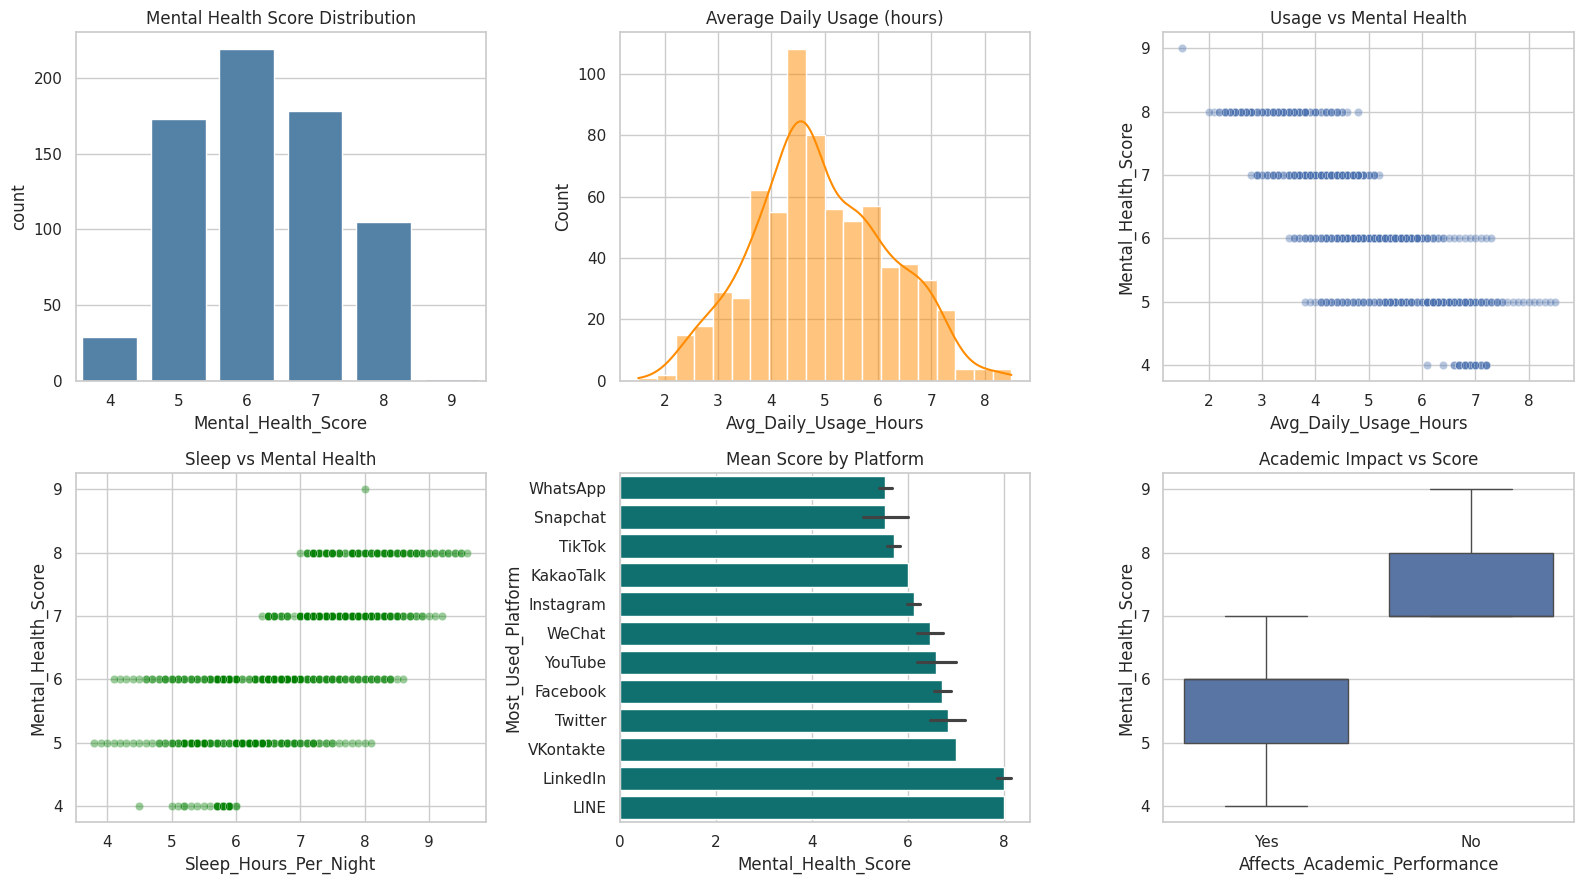

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9))
sns.countplot(x="Mental_Health_Score", data=df, ax=ax[0,0], color="steelblue"); ax[0,0].set_title("Mental Health Score Distribution")
sns.histplot(df["Avg_Daily_Usage_Hours"], bins=20, kde=True, ax=ax[0,1], color="darkorange"); ax[0,1].set_title("Average Daily Usage (hours)")
sns.scatterplot(x="Avg_Daily_Usage_Hours", y="Mental_Health_Score", data=df, alpha=.4, ax=ax[0,2]); ax[0,2].set_title("Usage vs Mental Health")
sns.scatterplot(x="Sleep_Hours_Per_Night", y="Mental_Health_Score", data=df, alpha=.4, ax=ax[1,0], color="green"); ax[1,0].set_title("Sleep vs Mental Health")
order = df.groupby("Most_Used_Platform").Mental_Health_Score.mean().sort_values().index
sns.barplot(y="Most_Used_Platform", x="Mental_Health_Score", data=df, order=order, ax=ax[1,1], color="teal"); ax[1,1].set_title("Mean Score by Platform")
sns.boxplot(x="Affects_Academic_Performance", y="Mental_Health_Score", data=df, ax=ax[1,2]); ax[1,2].set_title("Academic Impact vs Score")
plt.tight_layout(); plt.savefig("figures/eda_overview.png", dpi=150); plt.show()

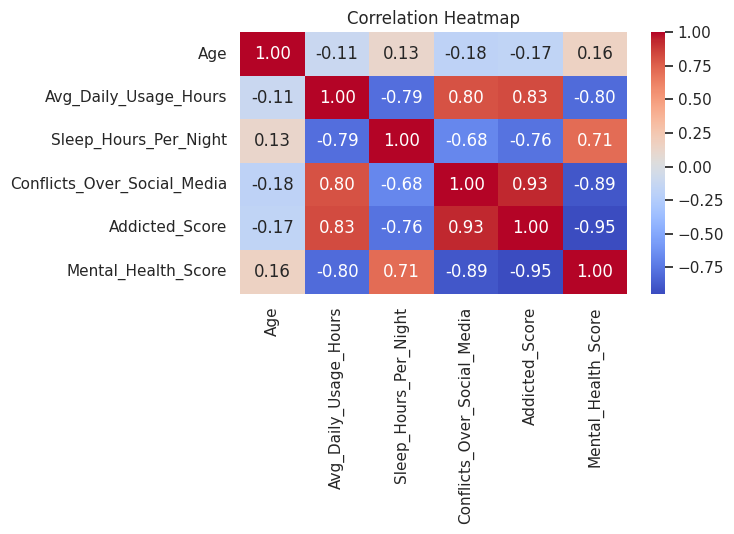

{
 "corr": {
  "Age": 0.16,
  "Avg_Daily_Usage_Hours": -0.801,
  "Sleep_Hours_Per_Night": 0.707,
  "Conflicts_Over_Social_Media": -0.894,
  "Addicted_Score": -0.945,
  "Mental_Health_Score": 1.0
 },
 "usage_bins": {
  "<=3h": 7.88,
  "3-5h": 6.72,
  "5-7h": 5.4,
  ">7h": 4.89
 },
 "sleep_bins": {
  "<=6h": 5.26,
  "6-7h": 5.74,
  "7-8h": 6.91,
  ">8h": 7.34
 },
 "academic": {
  "No": 7.42,
  "Yes": 5.56
 }
}


In [5]:
num = df[["Age","Avg_Daily_Usage_Hours","Sleep_Hours_Per_Night","Conflicts_Over_Social_Media","Addicted_Score","Mental_Health_Score"]]
corr = num.corr()
plt.figure(figsize=(7.5,5.5)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap"); plt.tight_layout(); plt.savefig("figures/correlation_heatmap.png", dpi=150); plt.show()

STATS["n_rows"], STATS["n_cols"] = df.shape
STATS["n_countries"] = int(df.Country.nunique())
STATS["score_mean"], STATS["score_std"] = float(df.Mental_Health_Score.mean()), float(df.Mental_Health_Score.std())
STATS["corr"] = corr["Mental_Health_Score"].round(3).to_dict()
STATS["usage_bins"] = df.groupby(pd.cut(df.Avg_Daily_Usage_Hours,[0,3,5,7,10], labels=["<=3h","3-5h","5-7h",">7h"])).Mental_Health_Score.mean().round(2).to_dict()
STATS["sleep_bins"] = df.groupby(pd.cut(df.Sleep_Hours_Per_Night,[0,6,7,8,12], labels=["<=6h","6-7h","7-8h",">8h"])).Mental_Health_Score.mean().round(2).to_dict()
STATS["academic"] = df.groupby("Affects_Academic_Performance").Mental_Health_Score.mean().round(2).to_dict()
STATS["platform"] = df.groupby("Most_Used_Platform").Mental_Health_Score.agg(["mean","count"]).round(2).sort_values("mean").to_dict("index")
STATS["gender"] = df.groupby("Gender").Mental_Health_Score.mean().round(2).to_dict()
STATS["level"] = df.groupby("Academic_Level").Mental_Health_Score.mean().round(2).to_dict()
print(json.dumps({k: STATS[k] for k in ["corr","usage_bins","sleep_bins","academic"]}, indent=1, default=str))

### EDA Summary
- The target is roughly bell-shaped (scores 4 to 9, mean about 6.2).
- **More daily usage goes with lower mental health scores** (strong negative correlation), while **more sleep goes with higher scores** (strong positive correlation).
- Students who say social media hurts their academic performance score noticeably lower.
- Platforms differ (see the bar chart), but several platforms have very few students, so those averages are unreliable.
- No missing values were found. *Country* (110 values) and *Most_Used_Platform* (12 values) have many categories, so rare ones need grouping.
- *Addicted_Score* and *Conflicts_Over_Social_Media* are very strongly (negatively) correlated with the target, so they are examined carefully in the preprocessing step.

## 1.4 Data Preprocessing

In [6]:
data = df.drop(columns=["Student_ID"]).copy()

# 1) Missing values – checked, none present
print("Missing values:", int(data.isnull().sum().sum()))

# 2) Group rare categories to avoid too many dummy columns
top_countries = data["Country"].value_counts()[lambda s: s >= 27].index.tolist()
top_platforms = data["Most_Used_Platform"].value_counts()[lambda s: s >= 30].index.tolist()
data["Grouped_country"]  = np.where(data["Country"].isin(top_countries), data["Country"], "Other")
data["Grouped_platform"] = np.where(data["Most_Used_Platform"].isin(top_platforms), data["Most_Used_Platform"], "Other")
data = data.drop(columns=["Country", "Most_Used_Platform"])

# 3) Binary encoding
data["Affects_Academic_Performance"] = data["Affects_Academic_Performance"].map({"No": 0, "Yes": 1})

# 4) Addicted_Score is a composite survey outcome (corr ~ -0.95 with target). Using it would let the
#    model 'read' the answer, so it is EXCLUDED from the main feature set (tested separately in 2.6).
addicted = data.pop("Addicted_Score")

print("Countries kept:", top_countries); print("Platforms kept:", top_platforms)
data.head()

Missing values: 0
Countries kept: ['India', 'USA', 'Canada', 'France', 'Spain', 'Mexico', 'Denmark', 'Switzerland', 'Ireland', 'Turkey']
Platforms kept: ['Instagram', 'TikTok', 'Facebook', 'WhatsApp', 'Twitter']


,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Grouped_country,Grouped_platform
0,19,Female,Undergraduate,5.2,1,6.5,6,In Relationship,3,Other,Instagram
1,22,Male,Graduate,2.1,0,7.5,8,Single,0,India,Twitter
2,20,Female,Undergraduate,6.0,1,5.0,5,Complicated,4,USA,TikTok
3,18,Male,High School,3.0,0,7.0,7,Single,1,Other,Other
4,21,Male,Graduate,4.5,1,6.0,6,In Relationship,2,Canada,Facebook


In [7]:
num_cols = ["Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Conflicts_Over_Social_Media"]
bin_cols = ["Affects_Academic_Performance"]
cat_cols = ["Gender", "Academic_Level", "Relationship_Status", "Grouped_platform", "Grouped_country"]

# One-hot encoding for categoricals + standardisation of numeric columns, all inside ONE pipeline step,
# so the same preprocessing is applied automatically in the web app.
def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bin", "passthrough", bin_cols)])

X = data.drop(columns=["Mental_Health_Score"]); y = data["Mental_Health_Score"]
print("Features used:", list(X.columns))

Features used: ['Age', 'Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Grouped_country', 'Grouped_platform']


## 1.5 Train / Test Split (80% / 20%)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RS)
print("Train:", X_train.shape, "Test:", X_test.shape)
STATS["n_train"], STATS["n_test"] = len(X_train), len(X_test)

Train: (564, 10) Test: (141, 10)


---
# Part 2: Model Implementation & Evaluation
Because the target is a continuous score, **regression** models are used. Five algorithms from the allowed list:
Linear Regression, Decision Tree, Random Forest, Support Vector Machine (SVR) and k-Nearest Neighbors.

## 2.1 Model Implementation & Training

In [9]:
def pipe(model): return Pipeline([("prep", make_preprocessor()), ("model", model)])

models = {
    "Linear Regression": pipe(LinearRegression()),
    "Decision Tree":     pipe(DecisionTreeRegressor(random_state=RS)),
    "Random Forest":     pipe(RandomForestRegressor(random_state=RS)),
    "SVM (SVR)":         pipe(SVR()),
    "k-NN":              pipe(KNeighborsRegressor()),
}
for n, m in models.items():
    m.fit(X_train, y_train); print("Trained:", n)

Trained: Linear Regression
Trained: Decision Tree


Trained: Random Forest
Trained: SVM (SVR)
Trained: k-NN


## 2.2 Model Evaluation (baseline models)

In [10]:
def evaluate(m, Xt, yt):
    p = m.predict(Xt)
    return {"MAE": mean_absolute_error(yt, p), "RMSE": np.sqrt(mean_squared_error(yt, p)), "R2": r2_score(yt, p)}
base = pd.DataFrame({n: evaluate(m, X_test, y_test) for n, m in models.items()}).T.round(4)
base

,MAE,RMSE,R2
Linear Regression,0.2797,0.3802,0.8796
Decision Tree,0.1418,0.3766,0.8819
Random Forest,0.1832,0.3253,0.9118
SVM (SVR),0.2165,0.3456,0.9005
k-NN,0.2043,0.3628,0.8904


## 2.3 Hyperparameter Tuning & Cross-Validation
**GridSearchCV** (5-fold, scoring = R²) is applied to Decision Tree, Random Forest, SVR and k-NN (the assignment needs at least one).
Linear Regression has no hyperparameters to tune. 5-fold cross-validation is then reported for **all** models.

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=RS)
grids = {
    "Decision Tree": {"model__max_depth": [3, 5, 7, 10, None], "model__min_samples_leaf": [1, 5, 10, 20]},
    "Random Forest": {"model__n_estimators": [100, 200, 300], "model__max_depth": [5, 10, None],
                      "model__min_samples_leaf": [1, 3, 5]},
    "SVM (SVR)":     {"model__C": [0.1, 1, 10], "model__kernel": ["rbf", "linear"], "model__epsilon": [0.05, 0.1, 0.5]},
    "k-NN":          {"model__n_neighbors": [3, 5, 7, 9, 11, 15], "model__weights": ["uniform", "distance"]},
}
final, best_params, rows = dict(models), {}, []
for n, g in grids.items():
    gs = GridSearchCV(pipe(models[n].named_steps["model"].__class__()), g, cv=kf, scoring="r2", n_jobs=-1)
    if n in ("Decision Tree", "Random Forest"):
        gs.estimator.named_steps["model"].set_params(random_state=RS)
    gs.fit(X_train, y_train)
    final[n] = gs.best_estimator_
    best_params[n] = {k.replace("model__", ""): v for k, v in gs.best_params_.items()}
    rows.append({"Model": n, "Best params": str(best_params[n]), "Best CV R2": round(gs.best_score_, 4)})
    print(n, "->", best_params[n], "| CV R2 = %.4f" % gs.best_score_)
pd.DataFrame(rows)

Decision Tree -> {'max_depth': 7, 'min_samples_leaf': 1} | CV R2 = 0.8998


Random Forest -> {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300} | CV R2 = 0.9291


SVM (SVR) -> {'C': 10, 'epsilon': 0.05, 'kernel': 'rbf'} | CV R2 = 0.9323


k-NN -> {'n_neighbors': 3, 'weights': 'distance'} | CV R2 = 0.9331


,Model,Best params,Best CV R2
0,Decision Tree,"{'max_depth': 7, 'min_samples_leaf': 1}",0.8998
1,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",0.9291
2,SVM (SVR),"{'C': 10, 'epsilon': 0.05, 'kernel': 'rbf'}",0.9323
3,k-NN,"{'n_neighbors': 3, 'weights': 'distance'}",0.9331


In [12]:
cv_rows = []
for n, m in final.items():
    s = cross_val_score(m, X_train, y_train, cv=kf, scoring="r2")
    cv_rows.append({"Model": n, "CV R2 mean": round(s.mean(), 4), "CV R2 std": round(s.std(), 4)})
cv_df = pd.DataFrame(cv_rows).set_index("Model"); cv_df

,CV R2 mean,CV R2 std
Model,,
Linear Regression,0.8552,0.0258
Decision Tree,0.8998,0.0199
Random Forest,0.9291,0.0152
SVM (SVR),0.9323,0.0139
k-NN,0.9331,0.0063


## 2.4 Final Comparison (tuned models on the test set)

,MAE,RMSE,R2,CV R2 mean,CV R2 std
Random Forest,0.1814,0.3210,0.9142,0.9291,0.0152
SVM (SVR),0.1750,0.3253,0.9118,0.9323,0.0139
Decision Tree,0.1908,0.3689,0.8867,0.8998,0.0199
k-NN,0.1532,0.3767,0.8818,0.9331,0.0063
Linear Regression,0.2797,0.3802,0.8796,0.8552,0.0258


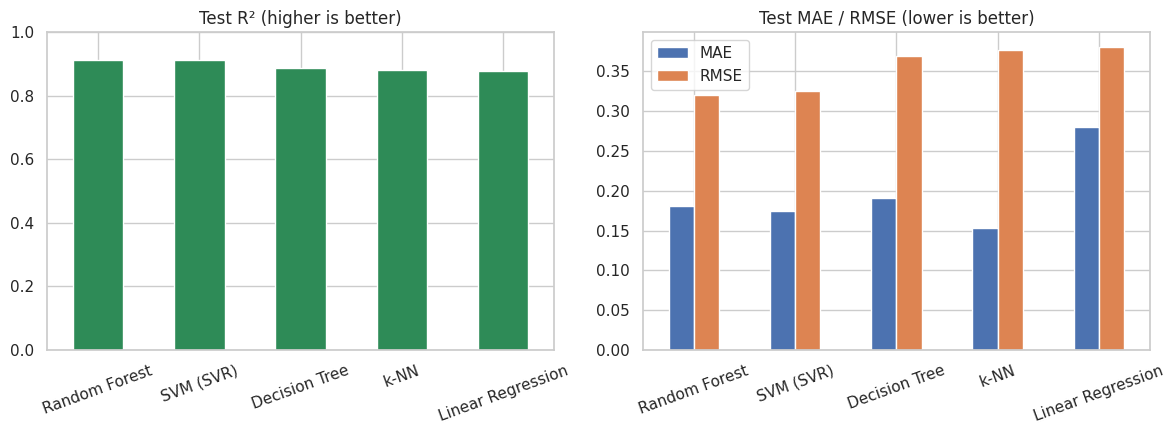

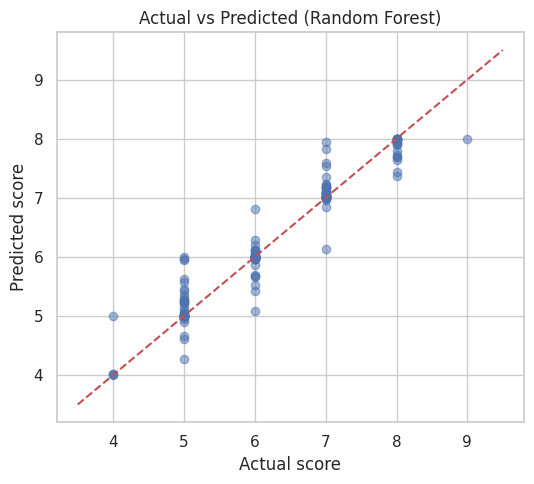

Best model on test R2: Random Forest


In [13]:
res = pd.DataFrame({n: evaluate(m, X_test, y_test) for n, m in final.items()}).T.round(4).join(cv_df)
res = res.sort_values("R2", ascending=False); display(res)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
res["R2"].plot(kind="bar", ax=ax[0], color="seagreen", rot=20); ax[0].set_title("Test R² (higher is better)"); ax[0].set_ylim(0,1)
res[["MAE","RMSE"]].plot(kind="bar", ax=ax[1], rot=20); ax[1].set_title("Test MAE / RMSE (lower is better)")
plt.tight_layout(); plt.savefig("figures/model_comparison.png", dpi=150); plt.show()

best_name = res.index[0]; bm = final[best_name]
pred = bm.predict(X_test)
plt.figure(figsize=(5.5,5)); plt.scatter(y_test, pred, alpha=.5)
plt.plot([3.5,9.5],[3.5,9.5],"r--"); plt.xlabel("Actual score"); plt.ylabel("Predicted score")
plt.title(f"Actual vs Predicted ({best_name})"); plt.tight_layout(); plt.savefig("figures/actual_vs_predicted.png", dpi=150); plt.show()
print("Best model on test R2:", best_name)

## 2.5 Feature Importance (permutation importance, best tree-based model)

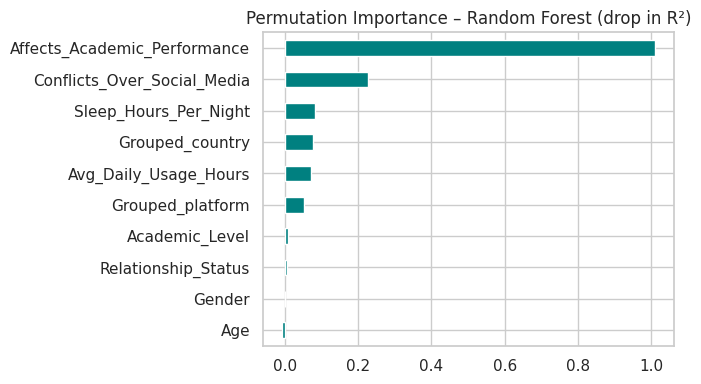

Affects_Academic_Performance    1.0107
Conflicts_Over_Social_Media     0.2271
Sleep_Hours_Per_Night           0.0832
Grouped_country                 0.0762
Avg_Daily_Usage_Hours           0.0733
Grouped_platform                0.0528
Academic_Level                  0.0105
Relationship_Status             0.0062
Gender                         -0.0001
Age                            -0.0070
dtype: float64

In [14]:
rf = final["Random Forest"]
pi = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=RS, scoring="r2")
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7,4)); imp.sort_values().plot(kind="barh", color="teal")
plt.title("Permutation Importance – Random Forest (drop in R²)"); plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=150); plt.show()
imp.round(4)

## 2.6 Extra check: effect of including `Addicted_Score`
`Addicted_Score` is a composite addiction measure from the same survey. To show why it was left out of the main feature set,
the Random Forest is re-trained with and without it.

In [15]:
X2 = X.copy(); X2["Addicted_Score"] = addicted.values
Xtr2, Xte2, ytr2, yte2 = train_test_split(X2, y, test_size=0.2, random_state=RS)
def make_prep2():
    return ColumnTransformer([("num", StandardScaler(), num_cols + ["Addicted_Score"]),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols), ("bin", "passthrough", bin_cols)])
rf_params = best_params["Random Forest"]
m2 = Pipeline([("prep", make_prep2()), ("model", RandomForestRegressor(random_state=RS, **rf_params))]).fit(Xtr2, ytr2)
abl = {"Without Addicted_Score (used)": evaluate(final["Random Forest"], X_test, y_test),
       "With Addicted_Score": evaluate(m2, Xte2, yte2)}
abl = pd.DataFrame(abl).T.round(4); STATS["ablation"] = abl.to_dict("index"); abl

,MAE,RMSE,R2
Without Addicted_Score (used),0.1814,0.3210,0.9142
With Addicted_Score,0.1146,0.2648,0.9416


## 2.7 Save models, preprocessing metadata and report numbers

In [16]:
fn = {"Linear Regression": "linear_regression", "Decision Tree": "decision_tree", "Random Forest": "random_forest",
      "SVM (SVR)": "svr", "k-NN": "knn"}
for n, m in final.items(): joblib.dump(m, f"models/{fn[n]}.joblib")

meta = {"top_countries": top_countries, "top_platforms": top_platforms,
        "all_countries": sorted(df.Country.unique().tolist()), "all_platforms": sorted(df.Most_Used_Platform.unique().tolist()),
        "file_names": fn, "feature_order": list(X.columns),
        "ranges": {"age": [int(df.Age.min()), int(df.Age.max())],
                   "usage": [float(df.Avg_Daily_Usage_Hours.min()), float(df.Avg_Daily_Usage_Hours.max())],
                   "sleep": [float(df.Sleep_Hours_Per_Night.min()), float(df.Sleep_Hours_Per_Night.max())]}}
joblib.dump(meta, "models/meta.joblib")

STATS["base"] = base.to_dict("index"); STATS["final"] = res.to_dict("index"); STATS["best_params"] = best_params
STATS["importance"] = imp.round(4).to_dict(); STATS["best_name"] = best_name
STATS["top_countries"], STATS["top_platforms"] = top_countries, top_platforms
json.dump(STATS, open("report_stats.json", "w"), indent=1, default=str)
print(sorted(os.listdir("models")))

['decision_tree.joblib', 'knn.joblib', 'linear_regression.joblib', 'meta.joblib', 'random_forest.joblib', 'svr.joblib']


## 2.8 Conclusions
Written after seeing the results – see the report for the full discussion. Summary: usage hours, sleep and conflicts over social media are the strongest
predictors of the mental health score; the models are trained on self-reported survey data, so the results show associations, **not causes**.